# Data Cleaning Notebook: Building Energy Efficiency Dataset

This notebook performs a rigorous cleaning and quality-assurance workflow for the **Energy Efficiency / Building Load** dataset.

The dataset contains eight building design covariates and two continuous response variables:

| Original | Clean Name | Meaning | Role |
|---|---|---|---|
| X1 | `relative_compactness` | Relative compactness | Predictor |
| X2 | `surface_area` | Surface area | Predictor |
| X3 | `wall_area` | Wall area | Predictor |
| X4 | `roof_area` | Roof area | Predictor |
| X5 | `overall_height` | Overall height | Predictor |
| X6 | `orientation` | Building orientation | Predictor |
| X7 | `glazing_area` | Glazing area | Predictor |
| X8 | `glazing_area_distribution` | Glazing area distribution | Predictor |
| Y1 | `heating_load` | Heating load requirement | Outcome |
| Y2 | `cooling_load` | Cooling load requirement | Outcome |


In [1]:
# ============================================================
# 1. IMPORTS AND GLOBAL SETTINGS
# ============================================================

import os
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42

## 2. Load the Raw Dataset

In [3]:
# ============================================================
# 2. LOAD DATA
# ============================================================

DATA_PATH = Path("/ENB2012_data2.xlsx")

if not DATA_PATH.exists():
    # Fallback for local execution after downloading the notebook and Excel file
    DATA_PATH = Path("ENB2012_data2.xlsx")

assert DATA_PATH.exists(), f"Data file not found: {DATA_PATH}"

excel_file = pd.ExcelFile(DATA_PATH)
print("Available sheet names:", excel_file.sheet_names)

raw_df = pd.read_excel(DATA_PATH, sheet_name=excel_file.sheet_names[0])
df_raw_backup = raw_df.copy(deep=True)

print("Raw shape:", raw_df.shape)
display(raw_df.head())
display(raw_df.tail())

Available sheet names: ['data']
Raw shape: (768, 10)


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.9800,514.5000,294.0000,110.2500,7.0000,2,0.0000,0,15.5500,21.3300
1,0.9800,514.5000,294.0000,110.2500,7.0000,3,0.0000,0,15.5500,21.3300
2,0.9800,514.5000,294.0000,110.2500,7.0000,4,0.0000,0,15.5500,21.3300
3,0.9800,514.5000,294.0000,110.2500,7.0000,5,0.0000,0,15.5500,21.3300
4,0.9000,563.5000,318.5000,122.5000,7.0000,2,0.0000,0,20.8400,28.2800


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
763,0.6400,784.0000,343.0000,220.5000,3.5000,5,0.4000,5,17.8800,21.4000
764,0.6200,808.5000,367.5000,220.5000,3.5000,2,0.4000,5,16.5400,16.8800
765,0.6200,808.5000,367.5000,220.5000,3.5000,3,0.4000,5,16.4400,17.1100
766,0.6200,808.5000,367.5000,220.5000,3.5000,4,0.4000,5,16.4800,16.6100
767,0.6200,808.5000,367.5000,220.5000,3.5000,5,0.4000,5,16.6400,16.0300


## 3. Standardize Column Names

In [ ]:
# ============================================================
#  RENAME COLUMNS AND DEFINE DATA DICTIONARY
# ============================================================

rename_map = {
    "X1": "relative_compactness",
    "X2": "surface_area",
    "X3": "wall_area",
    "X4": "roof_area",
    "X5": "overall_height",
    "X6": "orientation",
    "X7": "glazing_area",
    "X8": "glazing_area_distribution",
    "Y1": "heating_load",
    "Y2": "cooling_load",
}

expected_raw_columns = list(rename_map.keys())
missing_expected = [c for c in expected_raw_columns if c not in raw_df.columns]
unexpected_columns = [c for c in raw_df.columns if c not in expected_raw_columns]

print("Missing expected columns:", missing_expected)
print("Unexpected columns:", unexpected_columns)

assert not missing_expected, "Some required columns are missing. Check the uploaded file."

df = raw_df.rename(columns=rename_map).copy()

feature_cols = [
    "relative_compactness",
    "surface_area",
    "wall_area",
    "roof_area",
    "overall_height",
    "orientation",
    "glazing_area",
    "glazing_area_distribution",
]

target_cols = ["heating_load", "cooling_load"]

continuous_features = [
    "relative_compactness",
    "surface_area",
    "wall_area",
    "roof_area",
    "overall_height",
    "glazing_area",
]

categorical_features = ["orientation", "glazing_area_distribution"]

metadata = pd.DataFrame({
    "original_name": list(rename_map.keys()),
    "clean_name": list(rename_map.values()),
    "role": ["predictor"] * 8 + ["outcome"] * 2,
    "measurement_type": [
        "continuous", "continuous", "continuous", "continuous", "continuous",
        "categorical", "continuous", "categorical",
        "continuous", "continuous"
    ]
})

display(metadata)

Missing expected columns: []
Unexpected columns: []


,original_name,clean_name,role,measurement_type
0,X1,relative_compactness,predictor,continuous
1,X2,surface_area,predictor,continuous
2,X3,wall_area,predictor,continuous
3,X4,roof_area,predictor,continuous
4,X5,overall_height,predictor,continuous
5,X6,orientation,predictor,categorical/discrete
6,X7,glazing_area,predictor,continuous
7,X8,glazing_area_distribution,predictor,categorical/discrete
8,Y1,heating_load,outcome,continuous
9,Y2,cooling_load,outcome,continuous


## 4. Initial Structural Audit

This section checks the basic integrity of the dataset: shape, data types, missingness, uniqueness, duplicates, and numerical summaries.

In [ ]:
# ============================================================
# INITIAL STRUCTURAL AUDIT
# ============================================================

def structural_audit(data: pd.DataFrame) -> pd.DataFrame:
    audit = pd.DataFrame({
        "dtype": data.dtypes.astype(str),
        "non_null_count": data.notna().sum(),
        "missing_count": data.isna().sum(),
        "missing_percent": data.isna().mean() * 100,
        "unique_count": data.nunique(dropna=False),
    })
    return audit

print("Dataset shape:", df.shape)
display(structural_audit(df))

display(df.describe(include="all").T)

print("Exact duplicate rows:", df.duplicated().sum())

Dataset shape: (768, 10)


,dtype,non_null_count,missing_count,missing_percent,unique_count,duplicate_values_possible
relative_compactness,float64,768,0,0.0000,12,True
surface_area,float64,768,0,0.0000,12,True
wall_area,float64,768,0,0.0000,7,True
roof_area,float64,768,0,0.0000,4,True
overall_height,float64,768,0,0.0000,2,True
orientation,int64,768,0,0.0000,4,True
glazing_area,float64,768,0,0.0000,4,True
glazing_area_distribution,int64,768,0,0.0000,6,True
heating_load,float64,768,0,0.0000,587,True
cooling_load,float64,768,0,0.0000,636,True


,count,mean,std,min,25%,50%,75%,max
relative_compactness,768.0000,0.7642,0.1058,0.6200,0.6825,0.7500,0.8300,0.9800
surface_area,768.0000,671.7083,88.0861,514.5000,606.3750,673.7500,741.1250,808.5000
wall_area,768.0000,318.5000,43.6265,245.0000,294.0000,318.5000,343.0000,416.5000
roof_area,768.0000,176.6042,45.1660,110.2500,140.8750,183.7500,220.5000,220.5000
overall_height,768.0000,5.2500,1.7511,3.5000,3.5000,5.2500,7.0000,7.0000
orientation,768.0000,3.5000,1.1188,2.0000,2.7500,3.5000,4.2500,5.0000
glazing_area,768.0000,0.2344,0.1332,0.0000,0.1000,0.2500,0.4000,0.4000
glazing_area_distribution,768.0000,2.8125,1.5510,0.0000,1.7500,3.0000,4.0000,5.0000
heating_load,768.0000,22.3072,10.0902,6.0100,12.9925,18.9500,31.6675,43.1000
cooling_load,768.0000,24.5878,9.5133,10.9000,15.6200,22.0800,33.1325,48.0300


Exact duplicate rows: 0


## 5. Domain and Range Validation

In [6]:
# ============================================================
# DOMAIN AND RANGE VALIDATION
# ============================================================

expected_value_sets = {
    "orientation": {2, 3, 4, 5},
    "glazing_area_distribution": {0, 1, 2, 3, 4, 5},
    "glazing_area": {0.0, 0.1, 0.25, 0.4},
    "overall_height": {3.5, 7.0},
}

validation_records = []

for col, allowed in expected_value_sets.items():
    observed = set(df[col].dropna().unique().tolist())
    invalid = sorted(list(observed - allowed))
    missing_allowed = sorted(list(allowed - observed))
    validation_records.append({
        "column": col,
        "observed_values": sorted(list(observed)),
        "allowed_values": sorted(list(allowed)),
        "invalid_observed_values": invalid,
        "allowed_values_not_present": missing_allowed,
        "status": "PASS" if len(invalid) == 0 else "FAIL"
    })

value_set_report = pd.DataFrame(validation_records)
display(value_set_report)

# General physical plausibility checks
physical_checks = pd.DataFrame({
    "rule": [
        "surface_area > 0",
        "wall_area > 0",
        "roof_area > 0",
        "relative_compactness > 0",
        "heating_load > 0",
        "cooling_load > 0",
    ],
    "violations": [
        (df["surface_area"] <= 0).sum(),
        (df["wall_area"] <= 0).sum(),
        (df["roof_area"] <= 0).sum(),
        (df["relative_compactness"] <= 0).sum(),
        (df["heating_load"] <= 0).sum(),
        (df["cooling_load"] <= 0).sum(),
    ]
})

display(physical_checks)

,column,observed_values,allowed_values,invalid_observed_values,allowed_values_not_present,status
0,orientation,"[2, 3, 4, 5]","[2, 3, 4, 5]",[],[],PASS
1,glazing_area_distribution,"[0, 1, 2, 3, 4, 5]","[0, 1, 2, 3, 4, 5]",[],[],PASS
2,glazing_area,"[0.0, 0.1, 0.25, 0.4]","[0.0, 0.1, 0.25, 0.4]",[],[],PASS
3,overall_height,"[3.5, 7.0]","[3.5, 7.0]",[],[],PASS


,rule,violations
0,surface_area > 0,0
1,wall_area > 0,0
2,roof_area > 0,0
3,relative_compactness > 0,0
4,heating_load > 0,0
5,cooling_load > 0,0


## Duplicate and Repeated-Design Assessment

A distinction is made between:

1. **Exact duplicates**: all columns are identical.
2. **Repeated design points**: predictors are repeated, possibly with different outcomes.
3. **Conflicting duplicates**: same predictors but different target values.

For a controlled simulation dataset, repeated predictor settings may be expected only if the design truly repeats. Conflicting outcomes under identical predictors require careful review.

In [7]:
# ============================================================
# DUPLICATE AND REPEATED-DESIGN ASSESSMENT
# ============================================================

exact_duplicate_count = df.duplicated().sum()

feature_duplicate_count = df.duplicated(subset=feature_cols).sum()

conflict_check = (
    df.groupby(feature_cols, dropna=False)[target_cols]
      .nunique()
      .reset_index()
)

conflicting_designs = conflict_check[
    (conflict_check["heating_load"] > 1) | (conflict_check["cooling_load"] > 1)
]

duplicate_report = pd.DataFrame({
    "check": [
        "Exact duplicate rows",
        "Rows with repeated feature combinations",
        "Feature combinations with conflicting targets",
    ],
    "count": [exact_duplicate_count, feature_duplicate_count, len(conflicting_designs)]
})

display(duplicate_report)
display(conflicting_designs.head(20))

,check,count
0,Exact duplicate rows,0
1,Rows with repeated feature combinations,0
2,Feature combinations with conflicting targets,0


,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_distribution,heating_load,cooling_load


##  Outlier and Extreme-Value Diagnosis

Outliers are flagged using multiple methods:

- **IQR rule** for conventional distribution-free screening.
- **Z-score rule** for approximately normal variables.
- **Modified Z-score using MAD** for robust screening.

 **flags outliers but does not automatically delete them**.

In [8]:
# ============================================================
# OUTLIER AND EXTREME VALUE DIAGNOSIS
# ============================================================

numeric_cols = feature_cols + target_cols

outlier_flags = pd.DataFrame(index=df.index)
outlier_summary_records = []

for col in numeric_cols:
    series = df[col].astype(float)
    
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    iqr_flag = (series < lower) | (series > upper)
    
    z = np.abs(stats.zscore(series, nan_policy="omit"))
    z_flag = pd.Series(z > 3, index=df.index)
    
    median = series.median()
    mad = np.median(np.abs(series.dropna() - median))
    if mad == 0:
        modified_z_flag = pd.Series(False, index=df.index)
    else:
        modified_z = 0.6745 * (series - median) / mad
        modified_z_flag = modified_z.abs() > 3.5
    
    outlier_flags[f"{col}_iqr_outlier"] = iqr_flag
    outlier_flags[f"{col}_z_outlier"] = z_flag
    outlier_flags[f"{col}_modified_z_outlier"] = modified_z_flag
    
    outlier_summary_records.append({
        "column": col,
        "iqr_outliers": int(iqr_flag.sum()),
        "z_score_outliers": int(z_flag.sum()),
        "modified_z_outliers": int(modified_z_flag.sum()),
        "min": series.min(),
        "q1": q1,
        "median": series.median(),
        "q3": q3,
        "max": series.max(),
    })

outlier_summary = pd.DataFrame(outlier_summary_records)
display(outlier_summary)

# Add a row-level flag showing whether any variable was flagged by any method.
df["any_outlier_flag"] = outlier_flags.any(axis=1)
print("Rows flagged by at least one outlier rule:", df["any_outlier_flag"].sum())

,column,iqr_outliers,z_score_outliers,modified_z_outliers,min,q1,median,q3,max
0,relative_compactness,0,0,0,0.6200,0.6825,0.7500,0.8300,0.9800
1,surface_area,0,0,0,514.5000,606.3750,673.7500,741.1250,808.5000
2,wall_area,0,0,0,245.0000,294.0000,318.5000,343.0000,416.5000
3,roof_area,0,0,0,110.2500,140.8750,183.7500,220.5000,220.5000
4,overall_height,0,0,0,3.5000,3.5000,5.2500,7.0000,7.0000
5,orientation,0,0,0,2.0000,2.7500,3.5000,4.2500,5.0000
6,glazing_area,0,0,0,0.0000,0.1000,0.2500,0.4000,0.4000
7,glazing_area_distribution,0,0,0,0.0000,1.7500,3.0000,4.0000,5.0000
8,heating_load,0,0,0,6.0100,12.9925,18.9500,31.6675,43.1000
9,cooling_load,0,0,0,10.9000,15.6200,22.0800,33.1325,48.0300


Rows flagged by at least one outlier rule: 0


## Visual Distribution Checks

These plots help verify skewness, spread, discreteness, and possible irregular patterns.

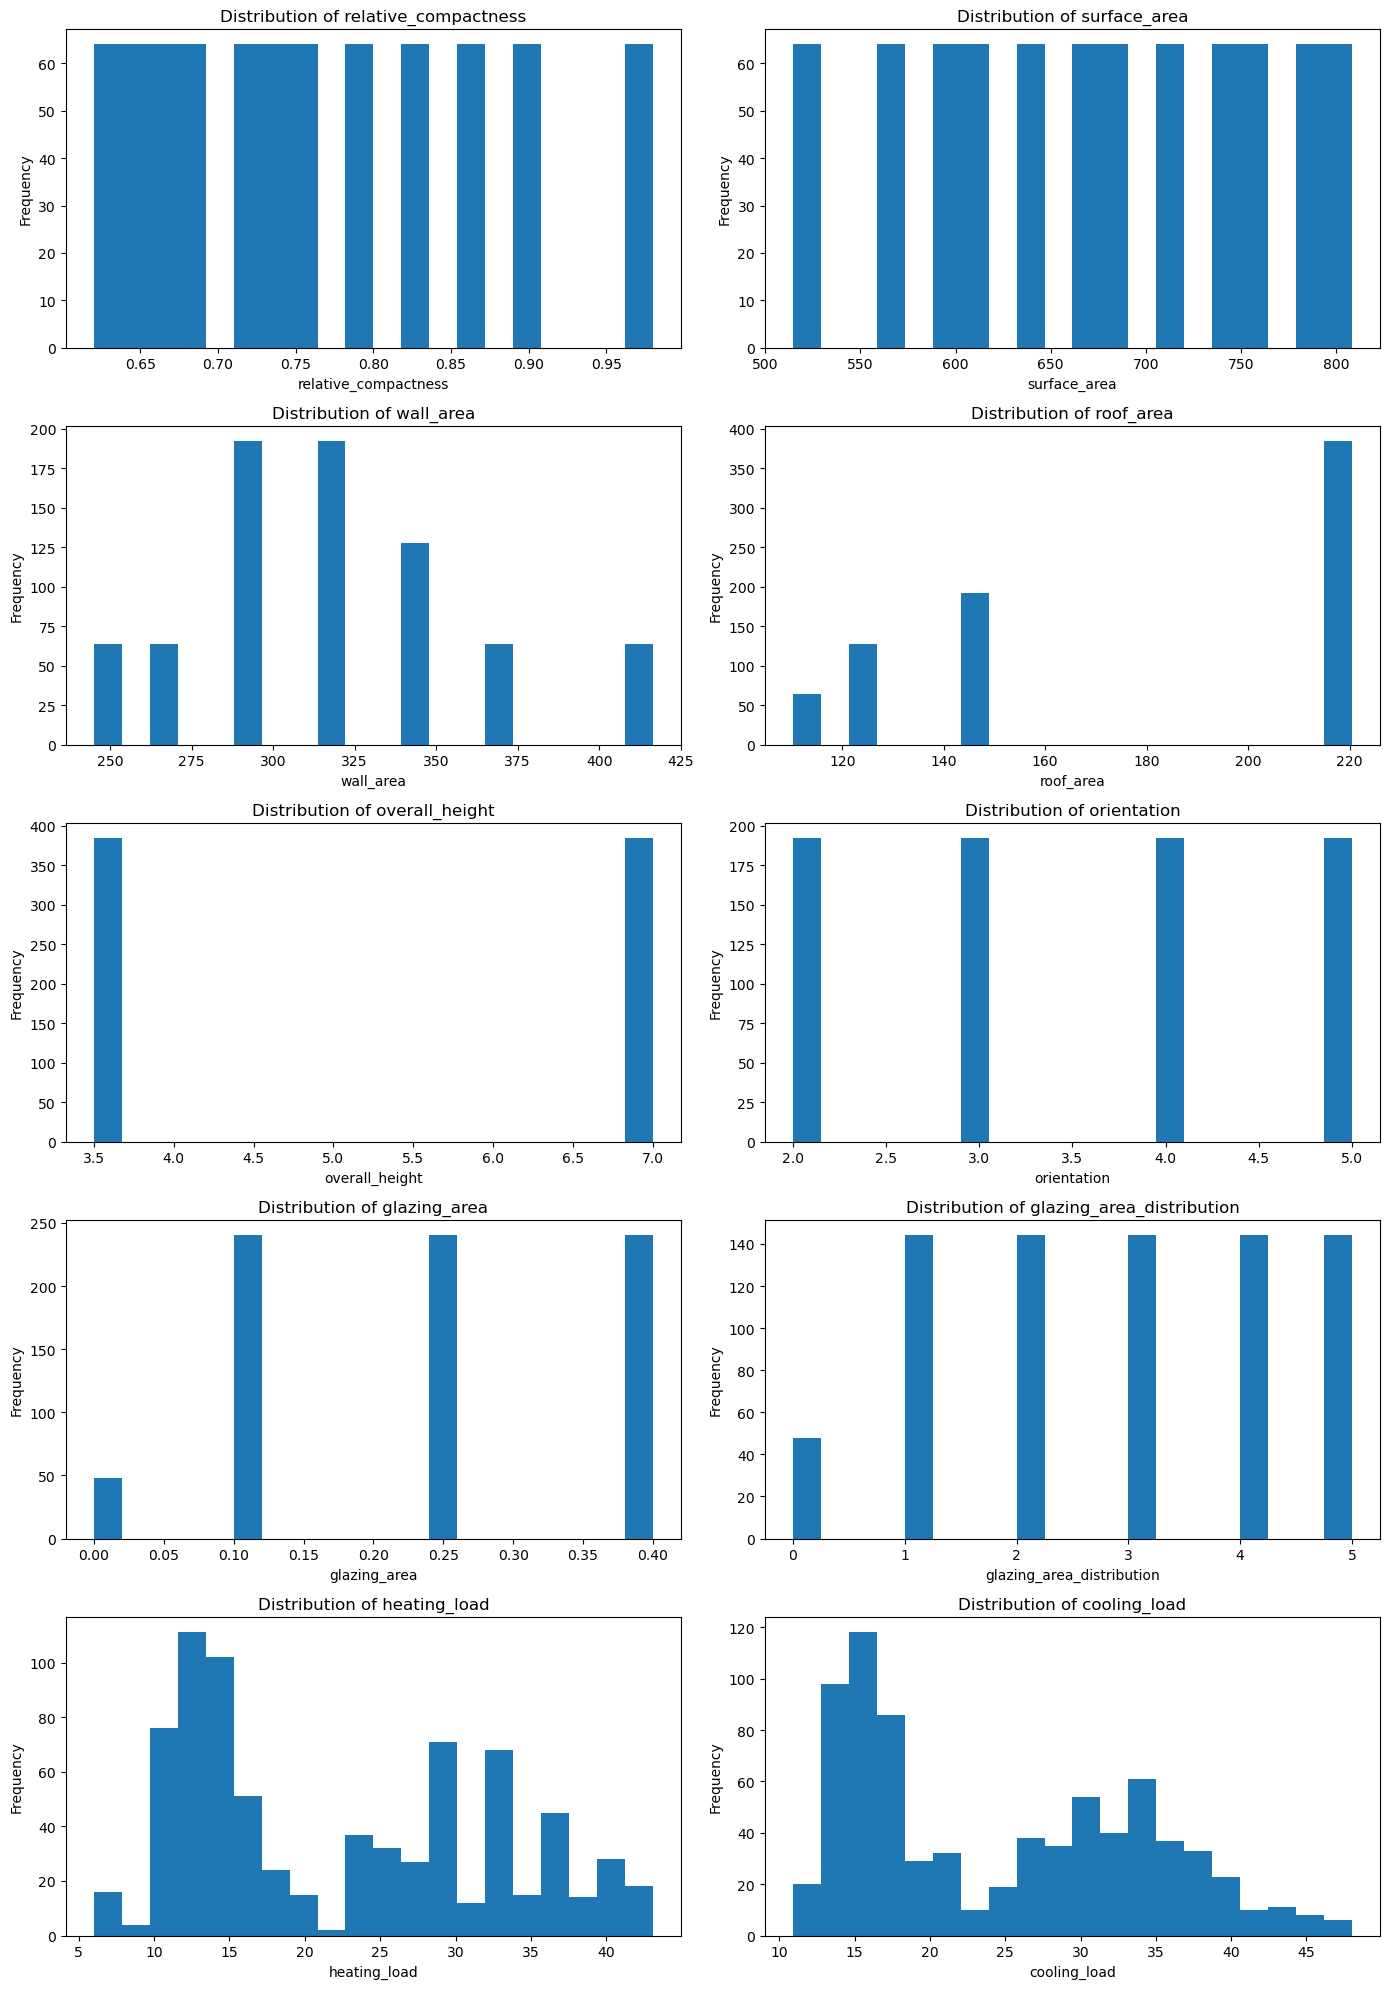

In [9]:
# ============================================================
# VISUAL DISTRIBUTION CHECKS
# ============================================================

n_cols = 2
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=20)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Target Relationship and Leakage Checks

The outcomes `heating_load` and `cooling_load` are both response variables. They should not be used as predictors for each other unless multi-output or chained prediction.

,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_distribution,heating_load,cooling_load
relative_compactness,1.0000,-0.9919,-0.2038,-0.8688,0.8277,0.0000,-0.0000,-0.0000,0.6223,0.6343
surface_area,-0.9919,1.0000,0.1955,0.8807,-0.8581,-0.0000,0.0000,0.0000,-0.6581,-0.6730
wall_area,-0.2038,0.1955,1.0000,-0.2923,0.2810,-0.0000,-0.0000,0.0000,0.4557,0.4271
roof_area,-0.8688,0.8807,-0.2923,1.0000,-0.9725,-0.0000,-0.0000,-0.0000,-0.8618,-0.8625
overall_height,0.8277,-0.8581,0.2810,-0.9725,1.0000,0.0000,0.0000,-0.0000,0.8894,0.8958
orientation,0.0000,-0.0000,-0.0000,-0.0000,0.0000,1.0000,-0.0000,-0.0000,-0.0026,0.0143
glazing_area,-0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,1.0000,0.2130,0.2698,0.2075
glazing_area_distribution,-0.0000,0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.2130,1.0000,0.0874,0.0505
heating_load,0.6223,-0.6581,0.4557,-0.8618,0.8894,-0.0026,0.2698,0.0874,1.0000,0.9759
cooling_load,0.6343,-0.6730,0.4271,-0.8625,0.8958,0.0143,0.2075,0.0505,0.9759,1.0000


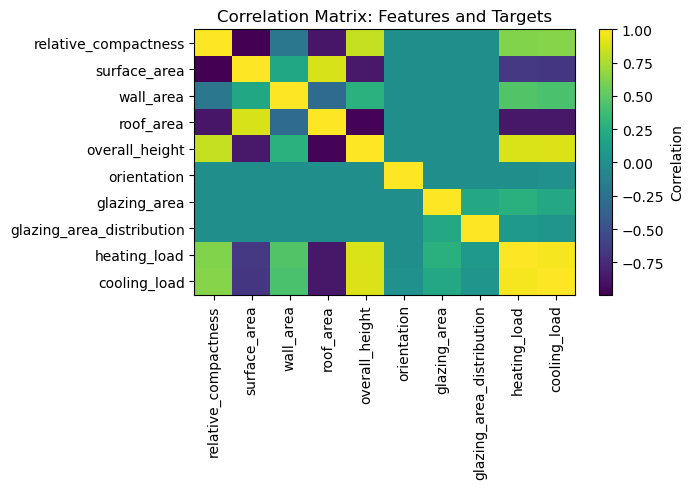

Correlation between heating_load and cooling_load: 0.9758617391437692


In [10]:
# ============================================================
# TARGET RELATIONSHIP AND LEAKAGE CHECKS
# ============================================================

corr = df[feature_cols + target_cols].corr(numeric_only=True)
display(corr)

plt.figure(figsize=(7, 5))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix: Features and Targets")
plt.tight_layout()
plt.show()

print("Correlation between heating_load and cooling_load:", df["heating_load"].corr(df["cooling_load"]))

##  Multicollinearity

Because this dataset contains geometric variables, some predictors are mathematically related. For example, `surface_area`, `wall_area`, and `roof_area` are structurally connected. This matters for parametric regression models.

In [11]:
# ============================================================
# MULTICOLLINEARITY / REDUNDANCY SCREENING
# ============================================================

feature_corr = df[feature_cols].corr(numeric_only=True)
display(feature_corr)

# Pairs with very high absolute correlation.
high_corr_pairs = []
for i, col1 in enumerate(feature_corr.columns):
    for col2 in feature_corr.columns[i+1:]:
        r = feature_corr.loc[col1, col2]
        if abs(r) >= 0.90:
            high_corr_pairs.append({"feature_1": col1, "feature_2": col2, "correlation": r})

high_corr_pairs = pd.DataFrame(high_corr_pairs)
display(high_corr_pairs)

,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_distribution
relative_compactness,1.0000,-0.9919,-0.2038,-0.8688,0.8277,0.0000,-0.0000,-0.0000
surface_area,-0.9919,1.0000,0.1955,0.8807,-0.8581,-0.0000,0.0000,0.0000
wall_area,-0.2038,0.1955,1.0000,-0.2923,0.2810,-0.0000,-0.0000,0.0000
roof_area,-0.8688,0.8807,-0.2923,1.0000,-0.9725,-0.0000,-0.0000,-0.0000
overall_height,0.8277,-0.8581,0.2810,-0.9725,1.0000,0.0000,0.0000,-0.0000
orientation,0.0000,-0.0000,-0.0000,-0.0000,0.0000,1.0000,-0.0000,-0.0000
glazing_area,-0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,1.0000,0.2130
glazing_area_distribution,-0.0000,0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.2130,1.0000


,feature_1,feature_2,correlation
0,relative_compactness,surface_area,-0.9919
1,roof_area,overall_height,-0.9725


In [13]:
# ============================================================
# SAVE CLEAN DATA
# ============================================================

OUTPUT_DIR = Path("data/clean")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(
    OUTPUT_DIR / "clean_df.csv",
    index=False
)

print(f"Clean dataset saved to: {OUTPUT_DIR / 'clean_df.csv'}")

Clean dataset saved to: data\clean\clean_df.csv
